# Random Forest Regressor zur Modellverbesserung

Zielsetzung: 
- Aufbauend auf den im OLS-Notebook vorbereiteten und gespeicherten Metadaten, wird in diesem Notebook ein Random Forest Regressor implementiert. Ziel ist es, die Vorhersagegenauigkeit für die (log-transformierte) Like-Anzahl (likes_log) potenziell zu verbessern, indem nicht-lineare Zusammenhänge und Interaktionen besser erfasst werden. Die Hyperparameter werden mittels GridSearchCV optimiert und die Ergebnisse mit denen des OLS-Modells verglichen.

author: "Zhanna Davtyan"

***Hinweis:*** führen Sie dieses Notebook aus, nachdem Sie das `04 OLS-Modelltraining` Notebook ausgeführt haben, um die erforderlichen Metadaten zu generieren.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import pickle


from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder 
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import plot_tree


#### Laden der vorbereiteten Daten aus der Pickle-Datei

Die geladenen Daten sind die unprozessierten Versionen vor der Anwendung von StandardScaler und OneHotEncoder.

In [152]:
try:
    with open('ols_train_test_data.pkl', 'rb') as f:
        loaded_data = pickle.load(f)
    
    X_train = loaded_data['X_train']
    X_test = loaded_data['X_test']
    y_train = loaded_data['y_train']
    y_test = loaded_data['y_test']
    X = loaded_data['X'] # Der ursprüngliche X DataFrame vor dem Splitten 
    numerical_cols = loaded_data['numerical_cols'] # Numerische Spalten
    categorical_cols = loaded_data['categorical_cols'] # Kategoriale Spalten
    
    
    print("Daten erfolgreich aus 'ols_train_test_data.pkl' geladen.")
    print(f"Shape von X_train: {X_train.shape}, Shape von y_train: {y_train.shape}")
    print(f"Shape von X_test: {X_test.shape}, Shape von y_test: {y_test.shape}")
    print(f"Ursprüngliche Features in X: {X.columns.tolist()}")
    print(f"Geladene numerische Spalten für RF: {numerical_cols}")
    print(f"Geladene kategoriale Spalten für RF: {categorical_cols}")
except FileNotFoundError:
    print("FEHLER: 'ols_train_test_data.pkl' nicht gefunden. Das OLS-Notebook muss zuerst ausgeführt werden und die Datei korrekt gespeichert werden.")
except KeyError as e:
    print(f"FEHLER: Ein Schlüssel wurde in der Pickle-Datei nicht gefunden: {e}")


Daten erfolgreich aus 'ols_train_test_data.pkl' geladen.
Shape von X_train: (1180, 7), Shape von y_train: (1180,)
Shape von X_test: (788, 7), Shape von y_test: (788,)
Ursprüngliche Features in X: ['follower_count', 'comment_count', 'hashtag_count', 'is_verified', 'is_professional_account', 'account_category', 'is_business_account']
Geladene numerische Spalten für RF: ['comment_count', 'follower_count', 'hashtag_count']
Geladene kategoriale Spalten für RF: ['account_category', 'is_business_account', 'is_professional_account', 'is_verified']


### Definition des Preprocessors für Random Forest

Für categorical_pipeline wird jetzt drop=None beim OneHotEncoder verwendet. Das behält alle Kategorien bei Das ist für Random Forests oft besser, da sie weniger anfällig für Multikollinearität sind und so die volle Information aus den kategorialen Variablen genutzt wird.

In [153]:
numerical_pipeline = Pipeline([
    ('imputer_num', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer_cat', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop=None))
])

preprocessor = ColumnTransformer([
    ('numerical', numerical_pipeline, numerical_cols),
    ('categorical', categorical_pipeline, categorical_cols)
], remainder='drop')

### Definition der Evaluierungs- und Plotfunktionen

In [154]:
def regressionSummary(y_true, y_pred):
    """ Gibt die wichtigsten Regressionsmetriken aus. """
    print('\nRegressionskennzahlen (basierend auf übergebenen Daten):\n')
    metrics = [
        ('Mean Squared Error (MSE)', mean_squared_error(y_true, y_pred)),
        ('Root Mean Squared Error (RMSE)', np.sqrt(mean_squared_error(y_true, y_pred))),
        ('Mean Absolute Error (MAE)', mean_absolute_error(y_true, y_pred)),
        ('R-squared (R2)', r2_score(y_true, y_pred))
    ]
    maxlength = max(len(m[0]) for m in metrics)
    fmt1 = f'{{:<{maxlength}}} : {{:.4f}}'
    for metric, value in metrics:
        print(fmt1.format(metric, value))
    

def plot_actual_vs_predicted_rf(y_true, y_pred, model_name="Random Forest"):
    y_true_np = y_true.values if isinstance(y_true, pd.Series) else y_true
    y_pred_np = y_pred
    target_name = y_true.name if hasattr(y_true, 'name') else 'Zielvariable'
    
    plt.figure(figsize=(8,6))
    plt.scatter(y_true_np, y_pred_np, alpha=0.5, edgecolors='k', s=50, label='Vorhersagen')
    min_val = min(y_true_np.min(), y_pred_np.min()) if (len(y_true_np) > 0 and len(y_pred_np) > 0) else 0
    max_val = max(y_true_np.max(), y_pred_np.max()) if (len(y_true_np) > 0 and len(y_pred_np) > 0) else 1
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfekte Vorhersage')
    plt.xlabel(f'Tatsächliche {target_name}')
    plt.ylabel(f'Vorhergesagte {target_name}')
    plt.title(f'Tatsächlich vs. Vorhergesagt - {model_name} (Testdaten)')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_residuals_rf(y_true, y_pred, model_name="Random Forest"):
    y_true_np = y_true.values if isinstance(y_true, pd.Series) else y_true
    y_pred_np = y_pred
    residuals = y_true_np - y_pred_np
    
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=y_pred_np, y=residuals, alpha=0.5, edgecolors='k', s=50)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel('Vorhergesagte Werte')
    plt.ylabel('Residuen (Tatsächlich - Vorhergesagt)')
    plt.title(f'Residuenplot - {model_name}')
    plt.grid(True)
    plt.show()

def plot_residuals_qq_rf(y_true, y_pred, alpha=0.5):
    y_true_np = y_true.values if isinstance(y_true, pd.Series) else y_true
    y_pred_np = y_pred
    residuals = y_true_np - y_pred_np

    plt.figure(figsize=(8,6))
    (osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist="norm", plot=None)
    plt.scatter(osm, osr, alpha=alpha, edgecolor='k', s=40)
    plt.plot(osm, slope*osm + intercept, 'r-', lw=2)
    plt.title('Q-Q Plot der Residuen (Random Forest)')
    plt.xlabel('Theoretische Quantile')
    plt.ylabel('Residuen-Quantile')
    plt.grid(True)
    plt.show()


### Hyperparameter-Optimierung mit GridSearchCV für Random Forest
Ein einzelner Entscheidungsbaum neigt zum Overfitting. Random Forests, als Ensemble-Methode, reduzieren dieses Risiko durch Diversifizierung, z.B. durch Datenstichproben (Bagging) und Merkmalssubsets. Um die besten Hyperparameter für den Random Forest Regressor zu finden und die Modellleistung zu optimieren, wird GridSearchCV (Gittersuche) verwendet.  Ziel ist es, die Parameterkombination zu finden, die die beste Leistung (hier gemessen am R²-Wert) mittels Kreuzvalidierung auf den Trainingsdaten erzielt. Dies hilft, Overfitting zu reduzieren und die Generalisierungsfähigkeit des Modells zu verbessern.

- Verwendet 3-fache Kreuzvalidierung (3 Trainingsdurchläufe pro Parameter-Kombination)
- Optimiert auf R²-Wert (Bestimmtheitsmaß)

In [155]:
# Pipeline für Random Forest inklusive Preprocessing
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))# Alle CPU-Kerne nutzen
])

# Definition des Parameter-Gitters für GridSearchCV
param_grid_rf = {
    'regressor__n_estimators': [100, 200],              # Anzahl der Bäume im Forest
    'regressor__max_depth': [10, 20, None],             # Maximale Tiefe der Bäume 
    'regressor__min_samples_split': [10, 20, 40],       # Minimale Anzahl Samples für einen Split 
    'regressor__min_samples_leaf': [5, 10, 20],         # Minimale Anzahl Samples in einem Blattknoten
    'regressor__max_features': ['sqrt', 'log2', None]   # Anzahl Features für besten Split
}

print("Starte GridSearchCV für Random Forest...")
grid_search_rf = GridSearchCV(rf_pipeline, param_grid_rf, cv=3,
                              scoring='r2', n_jobs=-1, verbose=1)
grid_search_rf.fit(X_train, y_train)

print(f"\nBeste gefundene Parameter für Random Forest: {grid_search_rf.best_params_}")
print(f"\nBester mittlerer R²-Wert (Cross-Validation) auf Trainingsdaten: {grid_search_rf.best_score_:.4f}")

# Das beste Modell aus GridSearchCV
best_rf_model = grid_search_rf.best_estimator_

Starte GridSearchCV für Random Forest...
Fitting 3 folds for each of 162 candidates, totalling 486 fits

Beste gefundene Parameter für Random Forest: {'regressor__max_depth': 20, 'regressor__max_features': None, 'regressor__min_samples_leaf': 5, 'regressor__min_samples_split': 10, 'regressor__n_estimators': 100}

Bester mittlerer R²-Wert (Cross-Validation) auf Trainingsdaten: 0.8456


#### Ergebnisse der Hyperparameter-Optimierung:

- 486 einzelne Modelltrainings wurden durchgeführt
- Der Random Forest erklärt ~84,6% der Varianz in den Like-Zahlen
- Deutliche Verbesserung gegenüber dem OLS-Modell (66,7%)
- Dieser Wert stammt aus der Kreuzvalidierung und ist daher zuverlässiger als ein einzelner Train-Test-Split

### Evaluierung des optimierten Random Forest Modells

Evaluation des optimierten Random Forest Modells auf den separaten Testdaten. Dies gibt uns eine Einschätzung, wie gut das Modell auf ungesehenen Daten generalisiert.

In [156]:
print("\nModellevaluierung für Random Forest (Testdaten)...")

y_pred_test_rf = best_rf_model.predict(X_test)

# Regressionskennzahlen 
print("\n--- Random Forest: Metriken auf Testdaten (log-transformierte Likes) ---")
regressionSummary(y_test, y_pred_test_rf) 





Modellevaluierung für Random Forest (Testdaten)...

--- Random Forest: Metriken auf Testdaten (log-transformierte Likes) ---

Regressionskennzahlen (basierend auf übergebenen Daten):

Mean Squared Error (MSE)       : 1.6747
Root Mean Squared Error (RMSE) : 1.2941
Mean Absolute Error (MAE)      : 0.7193
R-squared (R2)                 : 0.8594


#### Interpretation der Ergebnisse:
- R-squared: 
    - Das Modell erklärt ca. 85.94% der Varianz in der log-transformierten Like-Anzahl (likes_log) auf den Testdaten. Dies ist ein sehr guter Wert und eine deutliche Verbesserung gegenüber dem OLS-Modell (das auf Testdaten einen R² von ca. 0.6510 erreichte).


--- Random Forest: Diagnostische Plots (Testdaten) ---


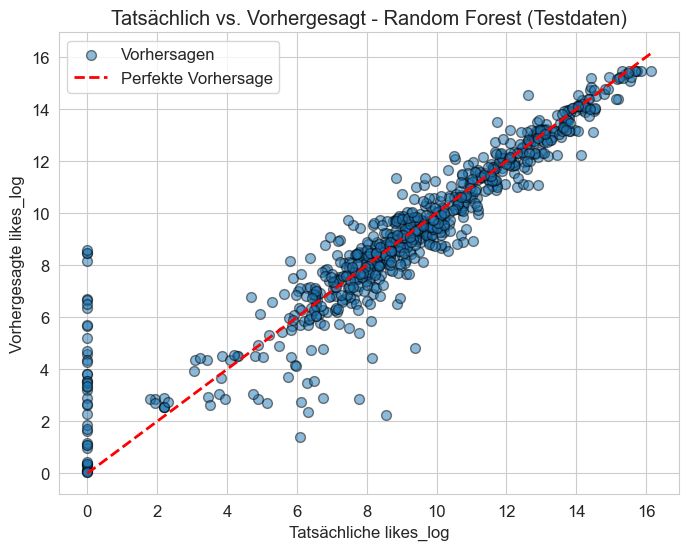

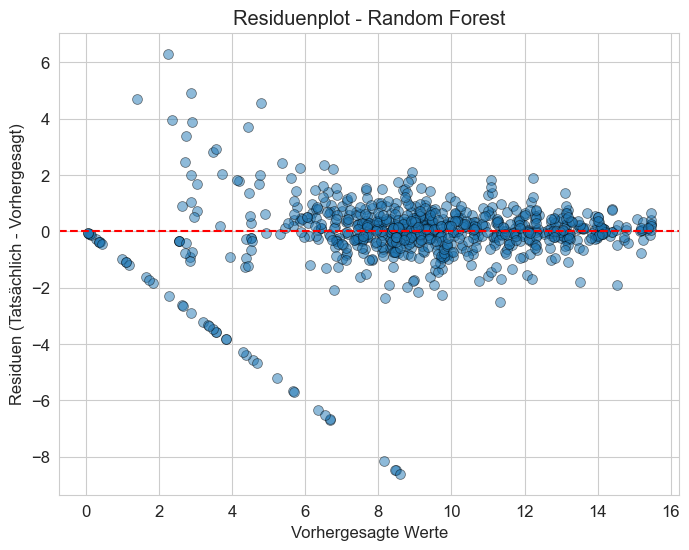

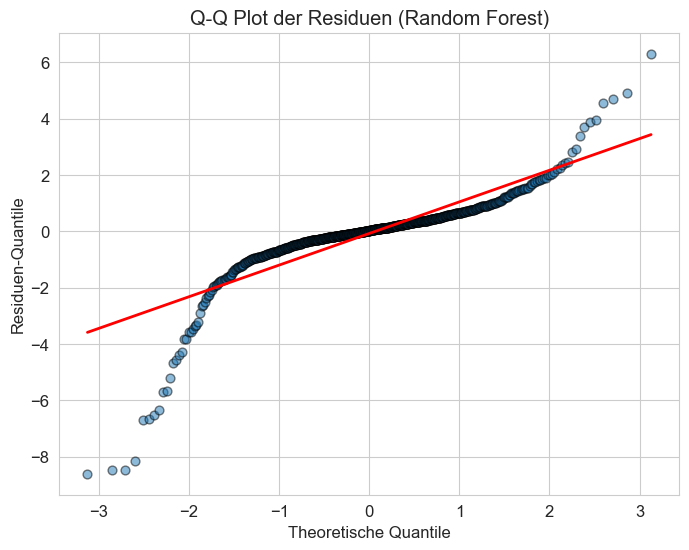

In [157]:
# die diagnostischen Plots
print("\n--- Random Forest: Diagnostische Plots (Testdaten) ---")
plot_actual_vs_predicted_rf(y_test, y_pred_test_rf, model_name="Random Forest")
plot_residuals_rf(y_test, y_pred_test_rf, model_name="Random Forest")
plot_residuals_qq_rf(y_test, y_pred_test_rf)

#### Interpretation der Ergebnisse:
1. Tatsächliche und vorhergesagte Like-Zahlen
    - Die Punkte im Scatterplot (log-transformierte Skala) liegen deutlich näher an der diagonalen Linie der perfekten Vorhersage als dies bei dem OLS-Modell mit den gleichen Daten der Fall war. Dies visualisiert die hohe Erklärungskraft des Random Forest Modells. Es gibt immer noch eine gewisse Streuung, was darauf hindeutet, dass das Modell Posts mit extrem vielen Likes möglicherweise immer noch nicht perfekt vorhersagt, aber insgesamt ist die Anpassung gut.

2. Residuenanalyse
    - Systematische Abweichung bei niedrigen vorhergesagten Werten.
    - Deutliches diagonales Muster mit stark negativen Residuen links im Diagramm.
    - Bessere Streuung um die Nulllinie im mittleren und oberen Bereich.
    - Trotz Random Forest bleibt ein systematisches Muster bestehen, was auf einen komplexen, nicht vollständig erfassten Zusammenhang bei niedrigen Like-Zahlen hindeutet.

3. Residuenverteilung
    - Deutliche Abweichung von der Normalverteilung (rote Linie).
    - S-förmige Kurve deutet auf schwerere Schwänze in beiden Richtungen hin.
Dies ist bei Random Forest Modellen weniger problematisch als bei OLS, da keine Normalverteilungsannahme erforderlich ist.

### Feature Importances des Random Forest Modells

Random Forests ermöglichen eine implizite Gewichtung der Attribute. Die Features werden extrahiert und die Relevanz des optimierten Modells zu visualisieren, um zu verstehen, welche Merkmale den größten Einfluss auf die Vorhersagen haben.

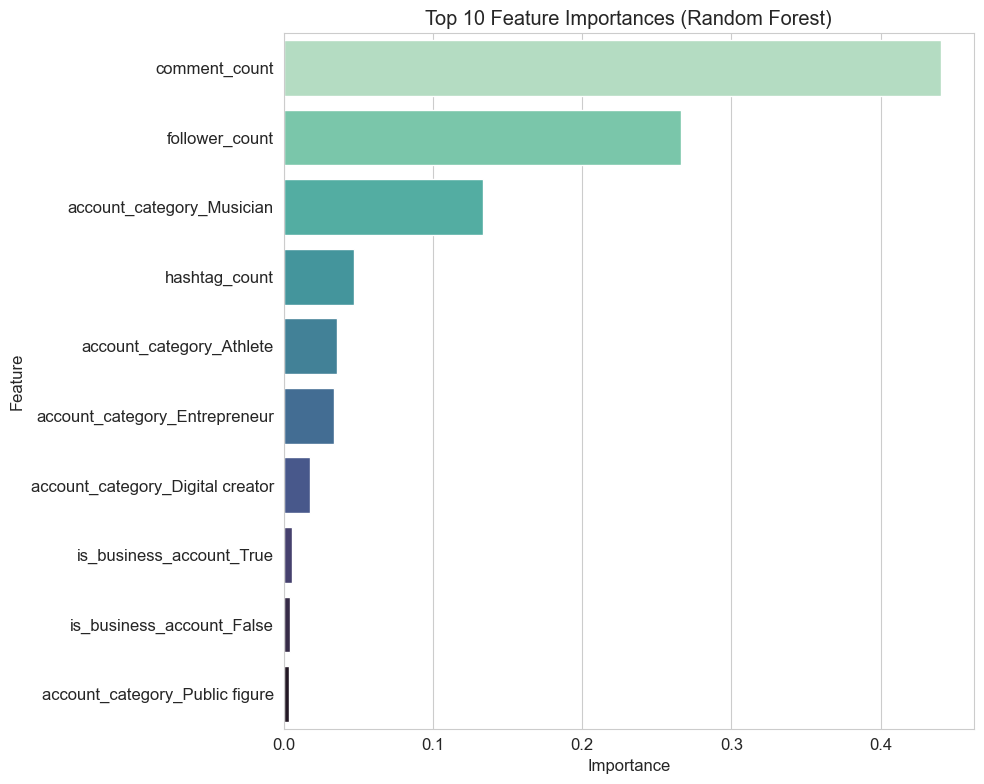

In [158]:
try:
    rf_regressor = best_rf_model.named_steps['regressor']
    preprocessor_fitted = best_rf_model.named_steps['preprocessor']

    transformed_feature = []
    
    # Numerische Features 
    if 'numerical_cols' in globals() and numerical_cols and preprocessor_fitted.named_transformers_.get('numerical'):
        transformed_feature.extend(numerical_cols)

    # One-Hot-kodierte Features 
    if 'categorical_cols' in globals() and categorical_cols and preprocessor_fitted.named_transformers_.get('categorical'):
        cat_pipeline_plot = preprocessor_fitted.named_transformers_['categorical']
        onehot_step_plot = cat_pipeline_plot.named_steps.get('onehot')
        if onehot_step_plot and hasattr(onehot_step_plot, 'get_feature_names_out'):
            onehot_feature_names_plot = onehot_step_plot.get_feature_names_out(categorical_cols)
            transformed_feature.extend(list(onehot_feature_names_plot))
        elif categorical_cols:
                print("WARNUNG: get_feature_names_out nicht verfügbar/erfolgreich für OHE im RF Plot.")
    
    if transformed_feature and hasattr(rf_regressor, 'feature_importances_') and \
        len(transformed_feature) == len(rf_regressor.feature_importances_):
        importances_rf_new = rf_regressor.feature_importances_
        feature_importance_rf_df_new = pd.DataFrame({'Feature': transformed_feature, 'Importance': importances_rf_new})
        feature_importance_rf_df_new = feature_importance_rf_df_new.sort_values(by='Importance', ascending=False).head(10)

        plt.figure(figsize=(10, 8))
        sns.barplot(x='Importance', y='Feature', data=feature_importance_rf_df_new, hue='Feature', palette='mako_r')
        plt.title('Top 10 Feature Importances (Random Forest)')
        plt.tight_layout()
        plt.show()
    else:
        print("Keine Feature Importances für RF verfügbar oder Feature-Namen konnten nicht extrahiert werden.")
except Exception as e:
    print(f"Fehler beim Plotten der RF Feature Importances: {e}")


### Interpretation 

- Dominante Features
    - comment_count: Ist mit Abstand das wichtigste Feature in deinem Random Forest Modell. Es deutet darauf hin, dass die Anzahl der Kommentare eine extrem hohe prädiktive Kraft für die Anzahl der Likes hat, sogar stärker als die reine Follower-Zahl in diesem nicht-linearen Modell. Hohe Kommentaranzahlen sind ein starkes Signal für Engagement, was oft direkt mit Likes korreliert.
    - follower_count: Ist das zweitwichtigste Feature. Das ist erwartungsgemäß, da die Anzahl der Follower die potenzielle Reichweite eines Posts bestimmt.
    - account_category_Musician: Diese spezifische Dummy-Variable (die angibt, ob der Account zur Kategorie "Musiker" gehört oder nicht) hat die dritthöchste Wichtigkeit. Dies unterstreicht, dass bestimmte Account-Nischen einen sehr deutlichen Einfluss haben. 
    - hashtag_count: Bleibt ein wichtiges Feature, auch wenn es nicht mehr so dominant negativ wie im OLS erschien (der RF kann komplexere Zusammenhänge abbilden).

### Visualisierung eines einzelnen Entscheidungsbaums 

Um ein besseres Gefühl für die Entscheidungsregeln zu bekommen, die der Random Forest lernt, können wir einen einzelnen Baum aus dem Ensemble visualisieren. Dies ist eine Vereinfachung, da der Forest aus vielen solchen Bäumen besteht, deren Vorhersagen aggregiert werden.

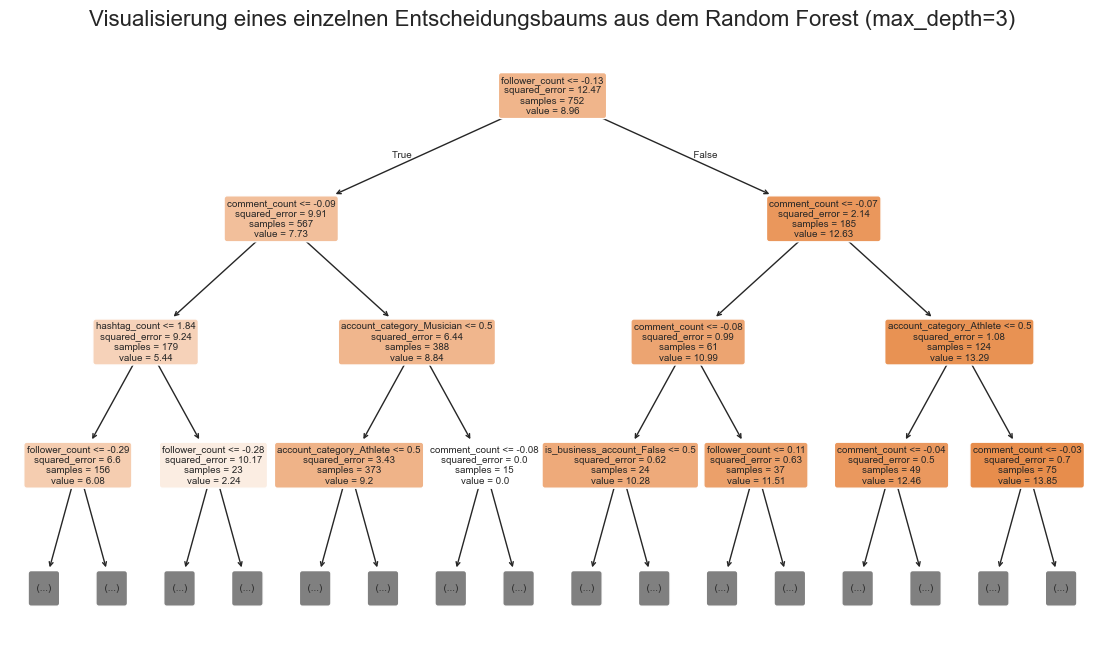

In [159]:
if 'best_rf_model' in locals() and best_rf_model is not None:
    try:
        rf_estimator_for_plot = best_rf_model.named_steps['regressor']     
        single_tree_to_plot = rf_estimator_for_plot.estimators_[0] 

        plt.figure(figsize=(14, 8)) 
        plot_tree(single_tree_to_plot,
                  feature_names=transformed_feature if 'transformed_feature' in locals() and transformed_feature else None,
                  filled=True,
                  rounded=True,
                  fontsize=7,
                  max_depth=3, # Begrenzung der Tiefe für die Visualisierung
                  precision=2) 
        plt.title("Visualisierung eines einzelnen Entscheidungsbaums aus dem Random Forest (max_depth=3)", fontsize=16)
        plt.show()
    except IndexError:
        print("Fehler: Der gewählte Baum-Index existiert nicht oder es sind keine Bäume im Modell.")
    except Exception as e:
        print(f"Fehler bei der Visualisierung des Baumes: {e}")
else:
    print("Random Forest Modell nicht trainiert/geladen, Baum kann nicht visualisiert werden.")

### Interpretation des visualisierten Entscheidungsbaums:

Ein einzelner Baum aus dem Forest wird visualisiert, um ein exemplarisches Verständnis dafür zu bekommen, wie das Modell Entscheidungen trifft und die Daten aufspaltet. Der Random Forest besteht aus vielen solcher Bäume, die auf unterschiedlichen Daten- und Feature-Subsets trainiert wurden, und deren Ergebnisse aggregiert werden. Dieser einzelne Baum ist also nicht repräsentativ für den gesamten Forest, gibt aber Einblicke in die Art der gelernten Regeln.

## Fazit

- Vorteile 
    - Die Ergebnisse stützen die Annahme, dass ein Random Forest aufgrund seiner Flexibilität und Robustheit gegenüber den strengen Annahmen der OLS-Regression besser für diesen Datensatz geeignet ist, um eine höhere Vorhersagegenauigkeit zu erzielen. Die verbesserte Verteilung der Residuen (weniger klare Muster im Residuenplot) ist ebenfalls ein positives Zeichen.

- Limitationen:
    - Obwohl leistungsstärker, ist ein Random Forest eine "Black Box". Die Feature Importances geben zwar eine globale Sicht auf die Wichtigkeit, aber die genaue Form der Zusammenhänge und Interaktionen ist weniger direkt ablesbar als bei OLS-Koeffizienten.

- Shlussfolgerung:
    - Das Random Forest ist ein aussagekräftigeres und verlässlicheres Modell für die Vorhersage der Likes und für die Identifizierung der insgesamt wichtigsten Einflussfaktoren, da es:
        - Keine strengen Verteilungsannahmen hat.
        - Nicht-Linearitäten und Interaktionen automatisch modellieren kann.
        - Eine deutlich bessere Vorhersageleistung auf den Testdaten gezeigt hat.